# Ablations: Hessian eigenspaces on MNIST + MLP3

Цель ноутбука:

1. Обучить `MLP3MNIST` обычным `SGD` на `MNIST-5k`.
2. Проверить, насколько меняется top-k подпространство гессиана при вычислении Hessian на разных размерах выборки: `full`, `90%`, `80%`, ...
3. Проверить, насколько top-k подпространство гессиана меняется между соседними шагами SGD.
4. Проверить низкоразмерность гессиана: доминируют ли первые `k = num_classes = 10` собственных направлений.
5. Построить график траекторий собственных чисел: одна линия = одно собственное число по шагам.

Вычисление Hessian top-k делается через `HessianEigenspaceProjector` с `solver="cola_lanczos"`

In [ ]:
from __future__ import annotations

import json
import math
import sys
import os
import time
from pathlib import Path
from typing import Any, Mapping

PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

sys.path.insert(0, os.path.abspath(".."))

PROJECT_ROOT: d:\Projects\where-do-gradient-methods-really-happen\notebooks


In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

from src.models.utils import seed_everything
from src.experiments.tasks import make_mnist_mlp3_task
from src.optimizers.sgd import SGD
from src.projections.hessian import HessianEigenspaceProjector

c:\ProgramData\miniconda3\envs\fmin-project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Config

Основные ручки:

- `STEPS`: сколько шагов SGD обучаем.
- `FULL_COMPARE_EVERY`: как часто считать top-10 Hessian basis на full dataset. Если стоит `1`, то соседние сравнения — действительно между соседними шагами SGD.
- `SUBSAMPLE_EVERY`: как часто сравнивать `full` vs `90%/80%/...`.
- `SPECTRUM_EVERY`: как часто считать top-`K_SPECTRUM` eigenvalues для графика траекторий собственных чисел.
- `K_COMPARE=10`: размерность проверяемого подпространства, равна числу классов.
- `K_SPECTRUM=30`: сколько eigenvalues считать для проверки низкоразмерности.

In [ ]:
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert DEVICE.type == "cuda", (
    "Этот ноутбук настроен на solver='cola_lanczos', который имеет смысл запускать на CUDA. "
    "Запусти на GPU или временно поменяй SOLVER='eigsh'."
)

DTYPE = torch.float32

NUM_CLASSES = 10
BATCH_SIZE = 50
LR = 0.01
LOSS_TYPE = "mse"

STEPS = 250

FULL_COMPARE_EVERY = 1

SUBSAMPLE_EVERY = 1

SPECTRUM_EVERY = 1

K_COMPARE = NUM_CLASSES
K_SPECTRUM = 30

BASIS_FRACTIONS = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]

SOLVER = "cola_lanczos"
TOL = 1e-4

MAXITER_COMPARE = None
MAXITER_SPECTRUM = None

OUT_DIR = Path("runs/ablations_mnist_mlp3")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_INTERMEDIATE = True
EMPTY_CUDA_CACHE_AFTER_HESSIAN = False

seed_everything(SEED)

print("device:", DEVICE)
print("torch:", torch.__version__)
try:
    import cola

    print("cola:", getattr(cola, "__version__", "installed"))
except Exception as e:
    raise RuntimeError(
        "cola-ml is required for solver='cola_lanczos'. Install/check cola before running."
    ) from e

device: cuda
torch: 2.12.0+cu126
cola: 0.0.7


## Task, model, optimizer

In [ ]:
task = make_mnist_mlp3_task(
    batch_size=BATCH_SIZE,
    num_workers=0,
    loss_type=LOSS_TYPE,
    num_classes=NUM_CLASSES,
)

model = task.model_factory().to(device=DEVICE, dtype=DTYPE)
model.train()

optimizer = SGD(model.parameters(), lr=LR)

params = list(model.parameters())
n_params = sum(p.numel() for p in params if p.requires_grad)

print(task.name)
print(model)
print("trainable parameters:", n_params)

mnist_mlp3
MLP3MNIST(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=200, bias=True)
    (2): Tanh()
    (3): Linear(in_features=200, out_features=200, bias=True)
    (4): Tanh()
    (5): Linear(in_features=200, out_features=10, bias=True)
  )
)
trainable parameters: 199210


## Fixed full MNIST-5k batch and nested subsets

In [ ]:
def batch_size(batch: Any) -> int:
    if torch.is_tensor(batch):
        return int(batch.shape[0])
    if isinstance(batch, Mapping):
        for v in batch.values():
            return batch_size(v)
        return 0
    if isinstance(batch, (tuple, list)):
        return batch_size(batch[0])
    raise TypeError(f"Cannot determine batch size for {type(batch).__name__}")


def index_batch(batch: Any, idx: torch.Tensor) -> Any:
    if torch.is_tensor(batch):
        return batch[idx]
    if isinstance(batch, tuple):
        return tuple(index_batch(x, idx) for x in batch)
    if isinstance(batch, list):
        return [index_batch(x, idx) for x in batch]
    if isinstance(batch, Mapping):
        return type(batch)({k: index_batch(v, idx) for k, v in batch.items()})
    raise TypeError(f"Cannot index batch of type {type(batch).__name__}")


def slice_batch(batch: Any, n: int) -> Any:
    if torch.is_tensor(batch):
        return batch[:n]
    if isinstance(batch, tuple):
        return tuple(slice_batch(x, n) for x in batch)
    if isinstance(batch, list):
        return [slice_batch(x, n) for x in batch]
    if isinstance(batch, Mapping):
        return type(batch)({k: slice_batch(v, n) for k, v in batch.items()})
    raise TypeError(f"Cannot slice batch of type {type(batch).__name__}")


dataset = task.train_loader.dataset

full_loader = DataLoader(
    dataset,
    batch_size=len(dataset),
    shuffle=False,
    num_workers=0,
    drop_last=False,
)

full_batch_cpu = next(iter(full_loader))
full_batch = task.batch_to_device(full_batch_cpu, DEVICE, DTYPE)

N_FULL = batch_size(full_batch)
gen = torch.Generator(device="cpu").manual_seed(SEED)
perm_cpu = torch.randperm(N_FULL, generator=gen)
perm = perm_cpu.to(DEVICE)

full_batch = index_batch(full_batch, perm)

basis_batches = {}
for frac in BASIS_FRACTIONS:
    n = int(round(N_FULL * frac))
    basis_batches[frac] = slice_batch(full_batch, n)

print("N_FULL:", N_FULL)
print({frac: batch_size(batch) for frac, batch in basis_batches.items()})

N_FULL: 5000
{1.0: 5000, 0.9: 4500, 0.8: 4000, 0.7: 3500, 0.6: 3000, 0.5: 2500}


## Metrics for comparing eigenvectors/subspaces

In [ ]:
def take_first_k(Q: torch.Tensor, k: int) -> torch.Tensor:
    return Q[:, :k].detach().cpu().float()


def subspace_stats(Q_ref: torch.Tensor, Q_other: torch.Tensor) -> dict[str, float]:
    Q_ref = Q_ref.detach().cpu().float()
    Q_other = Q_other.detach().cpu().float()

    s = torch.linalg.svdvals(Q_ref.T @ Q_other)
    alignment = torch.mean(s**2).item()
    mse = 1.0 - alignment

    return {
        "subspace_alignment": float(alignment),
        "subspace_mse": float(mse),
        "min_principal_cosine": float(s.min().item()),
        "mean_principal_cosine": float(s.mean().item()),
    }


def sign_aligned_vector_mse(
    Q_ref: torch.Tensor, Q_other: torch.Tensor
) -> dict[str, float]:
    Q_ref = Q_ref.detach().cpu().float()
    Q_other = Q_other.detach().cpu().float()

    dots = torch.sum(Q_ref * Q_other, dim=0)
    signs = torch.where(dots >= 0, torch.ones_like(dots), -torch.ones_like(dots))
    Q_aligned = Q_other * signs.unsqueeze(0)

    per_vec = torch.sum((Q_ref - Q_aligned) ** 2, dim=0)

    return {
        "vector_mse_l2_mean": float(per_vec.mean().item()),
        "vector_mse_l2_max": float(per_vec.max().item()),
    }


def lowdimensionality_stats(eigvals: torch.Tensor, k: int) -> dict[str, float]:
    vals = eigvals.detach().cpu().float()
    pos = torch.clamp(vals, min=0)

    eps = 1e-12
    topk_pos = pos[:k].sum()
    total_pos = pos.sum()

    if len(vals) > k:
        gap_k_next = vals[k - 1] / vals[k].clamp_min(eps)
        tail_pos = pos[k:].sum()
    else:
        gap_k_next = torch.tensor(float("nan"))
        tail_pos = torch.tensor(float("nan"))

    return {
        "topk_positive_mass_ratio": float((topk_pos / total_pos.clamp_min(eps)).item()),
        "tail_to_topk_positive_mass": float((tail_pos / topk_pos.clamp_min(eps)).item())
        if len(vals) > k
        else float("nan"),
        "eigengap_k_over_kplus1": float(gap_k_next.item())
        if len(vals) > k
        else float("nan"),
        "lambda_1": float(vals[0].item()),
        f"lambda_{k}": float(vals[k - 1].item()),
        f"lambda_{k+1}": float(vals[k].item()) if len(vals) > k else float("nan"),
    }

## Hessian top-k computation via CoLA Lanczos

Каждый projector держится как отдельный объект и переиспользуется между шагами. Это важно: ваша реализация warm-start-ит Lanczos с предыдущего top eigenvector, что ускоряет последовательные refresh-и basis.

In [ ]:
def make_hessian_projector(
    k: int, *, seed: int, maxiter: int | None
) -> HessianEigenspaceProjector:
    return HessianEigenspaceProjector(
        params,
        k=k,
        solver=SOLVER,
        which="LA",
        tol=TOL,
        maxiter=maxiter,
        seed=seed,
        device=DEVICE,
        dtype=torch.float32,
    )


full_compare_projector = make_hessian_projector(
    K_COMPARE,
    seed=SEED,
    maxiter=MAXITER_COMPARE,
)

full_spectrum_projector = make_hessian_projector(
    K_SPECTRUM,
    seed=SEED + 10_000,
    maxiter=MAXITER_SPECTRUM,
)

subset_projectors = {
    frac: make_hessian_projector(
        K_COMPARE,
        seed=SEED + int(frac * 10_000),
        maxiter=MAXITER_COMPARE,
    )
    for frac in BASIS_FRACTIONS
    if frac < 1.0
}


def update_hessian_projector(
    projector: HessianEigenspaceProjector,
    batch: Any,
) -> tuple[torch.Tensor, torch.Tensor, float]:
    was_training = model.training
    model.eval()

    def closure() -> torch.Tensor:
        return task.loss_fn(model, batch)

    t0 = time.perf_counter()
    projector.update_basis(closure)
    dt = time.perf_counter() - t0

    if was_training:
        model.train()

    Q = projector.basis.detach().cpu().float()
    eigvals = projector.eigvals.detach().cpu().float()

    if EMPTY_CUDA_CACHE_AFTER_HESSIAN and DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return Q, eigvals, dt

## Training step and evaluation functions

In [ ]:
def cycle(loader):
    while True:
        for batch in loader:
            yield batch


train_iter = cycle(task.train_loader)


def train_one_sgd_step() -> tuple[float, float]:
    batch = next(train_iter)
    batch = task.batch_to_device(batch, DEVICE, DTYPE)

    model.train()
    optimizer.zero_grad(set_to_none=True)

    loss = task.loss_fn(model, batch)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        if task.metrics_fn is not None:
            model.eval()
            metrics = task.metrics_fn(model, batch)
            model.train()
            acc = float(metrics.get("accuracy", float("nan")))
        else:
            acc = float("nan")

    return float(loss.detach().cpu()), acc


def should_eval(step: int, every: int) -> bool:
    return every is not None and every > 0 and (step % every == 0)

## Main loop

Что сохраняется:

- `train_rows`: loss/accuracy обычного SGD.
- `sample_rows`: сравнение `Q_subset` с `Q_full` для разных fractions.
- `neighbor_rows`: сравнение `Q_full(t)` с `Q_full(t-1)`; если `FULL_COMPARE_EVERY=1`, это соседние SGD steps.
- `eig_rows`: значения eigenvalue по шагам, для графика “одна линия = одно собственное число”.
- `lowdim_rows`: top-10 mass, eigengap, tail mass и т.д.

In [ ]:
train_rows: list[dict[str, Any]] = []
sample_rows: list[dict[str, Any]] = []
neighbor_rows: list[dict[str, Any]] = []
eig_rows: list[dict[str, Any]] = []
lowdim_rows: list[dict[str, Any]] = []

prev_full_Q: torch.Tensor | None = None
prev_full_step: int | None = None

last_full_Q: torch.Tensor | None = None
last_full_step: int | None = None


def save_tables() -> None:
    pd.DataFrame(train_rows).to_csv(OUT_DIR / "train.csv", index=False)
    pd.DataFrame(sample_rows).to_csv(OUT_DIR / "sample_size_ablation.csv", index=False)
    pd.DataFrame(neighbor_rows).to_csv(
        OUT_DIR / "neighbor_step_ablation.csv", index=False
    )
    pd.DataFrame(eig_rows).to_csv(OUT_DIR / "eigenvalue_trajectories.csv", index=False)
    pd.DataFrame(lowdim_rows).to_csv(OUT_DIR / "lowdimensionality.csv", index=False)


config_payload = {
    "seed": SEED,
    "device": str(DEVICE),
    "dtype": str(DTYPE),
    "steps": STEPS,
    "lr": LR,
    "loss_type": LOSS_TYPE,
    "k_compare": K_COMPARE,
    "k_spectrum": K_SPECTRUM,
    "basis_fractions": BASIS_FRACTIONS,
    "solver": SOLVER,
    "tol": TOL,
    "maxiter_compare": MAXITER_COMPARE,
    "maxiter_spectrum": MAXITER_SPECTRUM,
    "full_compare_every": FULL_COMPARE_EVERY,
    "subsample_every": SUBSAMPLE_EVERY,
    "spectrum_every": SPECTRUM_EVERY,
    "n_full": N_FULL,
    "n_params": n_params,
}
(OUT_DIR / "config.json").write_text(
    json.dumps(config_payload, indent=2), encoding="utf-8"
)


def evaluate_full_compare(step: int) -> torch.Tensor:
    global prev_full_Q, prev_full_step, last_full_Q, last_full_step

    Q_full, eigvals_full, dt = update_hessian_projector(
        full_compare_projector, basis_batches[1.0]
    )
    Q_full_k = take_first_k(Q_full, K_COMPARE)

    if prev_full_Q is not None and prev_full_step is not None:
        row = {
            "step_prev": prev_full_step,
            "step": step,
            "delta_steps": step - prev_full_step,
            "hessian_time_sec": dt,
        }
        row.update(
            {
                f"neighbor_{k}": v
                for k, v in subspace_stats(prev_full_Q, Q_full_k).items()
            }
        )
        row.update(
            {
                f"neighbor_{k}": v
                for k, v in sign_aligned_vector_mse(prev_full_Q, Q_full_k).items()
            }
        )
        neighbor_rows.append(row)

    prev_full_Q = Q_full_k
    prev_full_step = step
    last_full_Q = Q_full_k
    last_full_step = step

    return Q_full_k


def evaluate_spectrum(step: int) -> None:
    Q_spec, eigvals, dt = update_hessian_projector(
        full_spectrum_projector, basis_batches[1.0]
    )

    for i, val in enumerate(eigvals.tolist(), start=1):
        eig_rows.append(
            {
                "step": step,
                "eigen_idx": i,
                "eigenvalue": float(val),
                "hessian_time_sec": dt,
            }
        )

    row = {"step": step, "hessian_time_sec": dt}
    row.update(lowdimensionality_stats(eigvals, K_COMPARE))
    lowdim_rows.append(row)


def evaluate_subsample_ablation(step: int, Q_full_ref: torch.Tensor | None) -> None:
    if Q_full_ref is None:
        Q_full_ref = evaluate_full_compare(step)

    sample_rows.append(
        {
            "step": step,
            "fraction": 1.0,
            "n_samples": batch_size(basis_batches[1.0]),
            "subspace_alignment": 1.0,
            "subspace_mse": 0.0,
            "min_principal_cosine": 1.0,
            "mean_principal_cosine": 1.0,
            "vector_mse_l2_mean": 0.0,
            "vector_mse_l2_max": 0.0,
            "hessian_time_sec": 0.0,
        }
    )

    for frac in [f for f in BASIS_FRACTIONS if f < 1.0]:
        Q_sub, eigvals_sub, dt = update_hessian_projector(
            subset_projectors[frac], basis_batches[frac]
        )
        Q_sub_k = take_first_k(Q_sub, K_COMPARE)

        row = {
            "step": step,
            "fraction": frac,
            "n_samples": batch_size(basis_batches[frac]),
            "hessian_time_sec": dt,
        }
        row.update(subspace_stats(Q_full_ref, Q_sub_k))
        row.update(sign_aligned_vector_mse(Q_full_ref, Q_sub_k))
        sample_rows.append(row)

In [ ]:
if should_eval(0, FULL_COMPARE_EVERY):
    Q0 = evaluate_full_compare(0)
else:
    Q0 = None

if should_eval(0, SPECTRUM_EVERY):
    evaluate_spectrum(0)

if should_eval(0, SUBSAMPLE_EVERY):
    evaluate_subsample_ablation(0, Q0)

if SAVE_INTERMEDIATE:
    save_tables()

pbar = tqdm(range(1, STEPS + 1), desc="SGD + Hessian ablations")

for step in pbar:
    loss, acc = train_one_sgd_step()

    train_rows.append(
        {
            "step": step,
            "loss": loss,
            "accuracy": acc,
        }
    )

    Q_full_this_step = None

    if should_eval(step, FULL_COMPARE_EVERY):
        Q_full_this_step = evaluate_full_compare(step)

    if should_eval(step, SPECTRUM_EVERY):
        evaluate_spectrum(step)

    if should_eval(step, SUBSAMPLE_EVERY):
        evaluate_subsample_ablation(step, Q_full_this_step)

    if hasattr(pbar, "set_postfix"):
        pbar.set_postfix(loss=f"{loss:.4g}", acc=f"{acc:.3f}")

    if SAVE_INTERMEDIATE and (
        should_eval(step, SUBSAMPLE_EVERY)
        or should_eval(step, SPECTRUM_EVERY)
        or step == STEPS
    ):
        save_tables()

save_tables()

print("Saved to:", OUT_DIR.resolve())
print("train rows:", len(train_rows))
print("sample rows:", len(sample_rows))
print("neighbor rows:", len(neighbor_rows))
print("eigen rows:", len(eig_rows))
print("lowdim rows:", len(lowdim_rows))

SGD + Hessian ablations: 100%|██████████| 250/250 [06:25<00:00,  1.54s/it, acc=0.820, loss=0.4419]

Saved to: D:\Projects\where-do-gradient-methods-really-happen\notebooks\runs\ablations_mnist_mlp3
train rows: 250
sample rows: 1506
neighbor rows: 250
eigen rows: 7530
lowdim rows: 251


## Load results into DataFrames

In [ ]:
train_df = pd.read_csv(OUT_DIR / "train.csv")
sample_df = pd.read_csv(OUT_DIR / "sample_size_ablation.csv")
neighbor_df = pd.read_csv(OUT_DIR / "neighbor_step_ablation.csv")
eig_df = pd.read_csv(OUT_DIR / "eigenvalue_trajectories.csv")
lowdim_df = pd.read_csv(OUT_DIR / "lowdimensionality.csv")

display(train_df.head())
display(sample_df.head())
display(neighbor_df.head())
display(eig_df.head())
display(lowdim_df.head())

,step,loss,accuracy
0,1,1.141858,0.24
1,2,1.051608,0.36
2,3,0.930922,0.38
3,4,0.869820,0.36
4,5,0.853510,0.44


,step,fraction,n_samples,subspace_alignment,subspace_mse,min_principal_cosine,mean_principal_cosine,vector_mse_l2_mean,vector_mse_l2_max,hessian_time_sec
0,0,1.0,5000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
1,0,0.9,4500,0.999909,0.000091,0.999950,0.999954,0.000099,0.000106,0.155203
2,0,0.8,4000,0.999838,0.000162,0.999916,0.999919,0.000180,0.000197,0.131981
3,0,0.7,3500,0.999838,0.000162,0.999916,0.999919,0.000182,0.000199,0.132183
4,0,0.6,3000,0.999710,0.000290,0.999843,0.999855,0.000363,0.000444,0.132540


,step_prev,step,delta_steps,hessian_time_sec,neighbor_subspace_alignment,neighbor_subspace_mse,neighbor_min_principal_cosine,neighbor_mean_principal_cosine,neighbor_vector_mse_l2_mean,neighbor_vector_mse_l2_max
0,0,1,1,0.138826,0.989146,0.010854,0.988994,0.994556,0.014345,0.026725
1,1,2,1,0.133872,0.992166,0.007834,0.990769,0.996073,0.009740,0.016268
2,2,3,1,0.130698,0.994530,0.005470,0.994278,0.997261,0.006817,0.010354
3,3,4,1,0.131625,0.997790,0.002210,0.997567,0.998894,0.003632,0.007790
4,4,5,1,0.137458,0.997332,0.002668,0.997269,0.998665,0.004129,0.006898


,step,eigen_idx,eigenvalue,hessian_time_sec
0,0,1,69.249451,0.692536
1,0,2,59.458702,0.692536
2,0,3,56.076107,0.692536
3,0,4,51.769299,0.692536
4,0,5,48.707794,0.692536


,step,hessian_time_sec,topk_positive_mass_ratio,tail_to_topk_positive_mass,eigengap_k_over_kplus1,lambda_1,lambda_10,lambda_11
0,0,0.692536,0.671678,0.488808,2.098507,69.249451,31.760023,15.134580
1,1,0.668208,0.698070,0.432521,2.091381,68.660492,31.281595,14.957388
2,2,0.667933,0.706275,0.415879,2.102432,68.515991,31.066837,14.776618
3,3,0.660058,0.709913,0.408623,2.122992,68.551315,31.127832,14.662250
4,4,0.656704,0.711261,0.405953,2.138447,68.394684,31.176077,14.578838


## Plot 1: training loss / accuracy

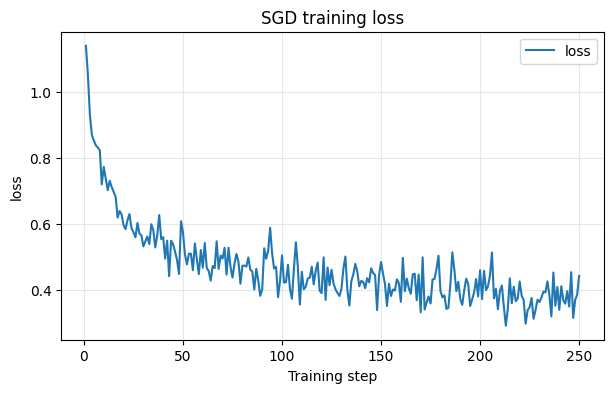

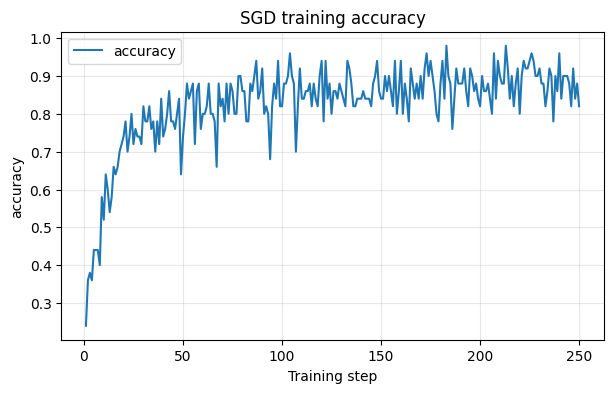

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_df["step"], train_df["loss"], label="loss")
ax.set_xlabel("Training step")
ax.set_ylabel("loss")
ax.set_title("SGD training loss")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_df["step"], train_df["accuracy"], label="accuracy")
ax.set_xlabel("Training step")
ax.set_ylabel("accuracy")
ax.set_title("SGD training accuracy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Plot 2: sample-size ablation

Сравнение top-10 Hessian subspace на subset-е с top-10 Hessian subspace на full MNIST-5k.

Чем ближе к нулю, тем ближе подпространства.

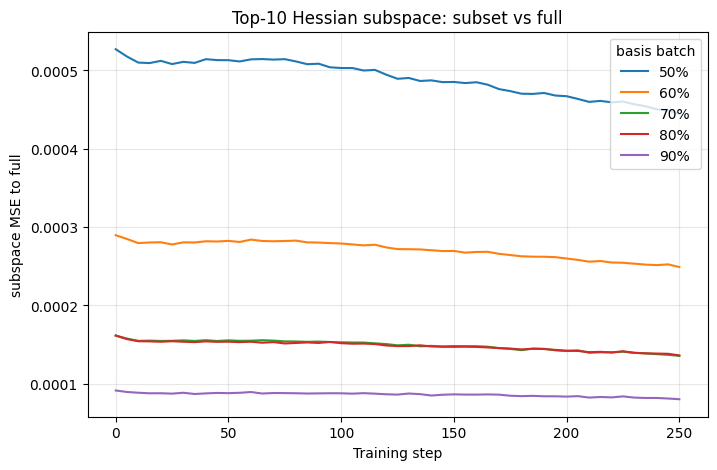

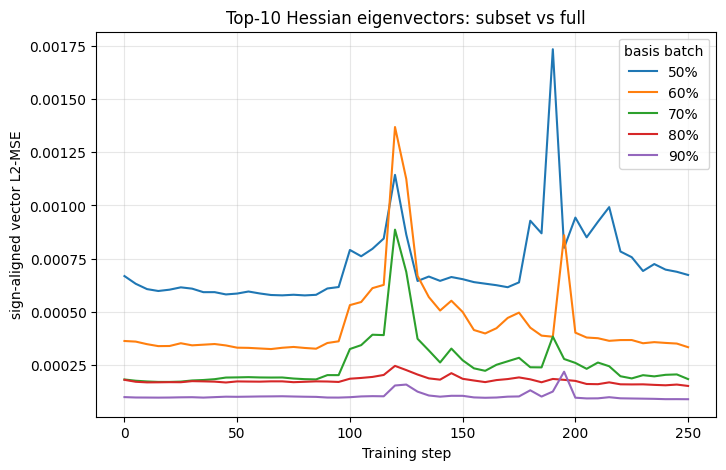

In [ ]:
plot_df = sample_df[sample_df["fraction"] < 1.0].copy()

fig, ax = plt.subplots(figsize=(8, 5))
for frac, g in plot_df.groupby("fraction"):
    ax.plot(g["step"], g["subspace_mse"], label=f"{int(frac * 100)}%")
ax.set_xlabel("Training step")
ax.set_ylabel("subspace MSE to full")
ax.set_title(f"Top-{K_COMPARE} Hessian subspace: subset vs full")
ax.grid(True, alpha=0.3)
ax.legend(title="basis batch")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for frac, g in plot_df.groupby("fraction"):
    ax.plot(g["step"], g["vector_mse_l2_mean"], label=f"{int(frac * 100)}%")
ax.set_xlabel("Training step")
ax.set_ylabel("sign-aligned vector L2-MSE")
ax.set_title(f"Top-{K_COMPARE} Hessian eigenvectors: subset vs full")
ax.grid(True, alpha=0.3)
ax.legend(title="basis batch")
plt.show()

In [ ]:
summary = (
    sample_df[sample_df["fraction"] < 1.0]
    .groupby("fraction")
    .agg(
        n_checkpoints=("step", "count"),
        n_samples=("n_samples", "first"),
        subspace_mse_mean=("subspace_mse", "mean"),
        subspace_mse_std=("subspace_mse", "std"),
        vector_mse_l2_mean=("vector_mse_l2_mean", "mean"),
        vector_mse_l2_std=("vector_mse_l2_mean", "std"),
        alignment_mean=("subspace_alignment", "mean"),
    )
    .reset_index()
)
display(summary)
summary.to_csv(OUT_DIR / "sample_size_ablation_summary.csv", index=False)

,fraction,n_checkpoints,n_samples,subspace_mse_mean,subspace_mse_std,vector_mse_l2_mean,vector_mse_l2_std,alignment_mean
0,0.5,51,2500,0.000490,0.000023,0.000719,0.000194,0.999510
1,0.6,51,3000,0.000271,0.000011,0.000445,0.000198,0.999729
2,0.7,51,3500,0.000149,0.000006,0.000256,0.000127,0.999851
3,0.8,51,4000,0.000148,0.000006,0.000177,0.000017,0.999852
4,0.9,51,4500,0.000086,0.000002,0.000105,0.000021,0.999914


## Plot 3: change between neighboring SGD steps

Если `FULL_COMPARE_EVERY = 1`, то это сравнение `Q_t` и `Q_{t-1}` на соседних SGD steps.  
Если `FULL_COMPARE_EVERY > 1`, то это сравнение соседних Hessian-checkpoint-ов.

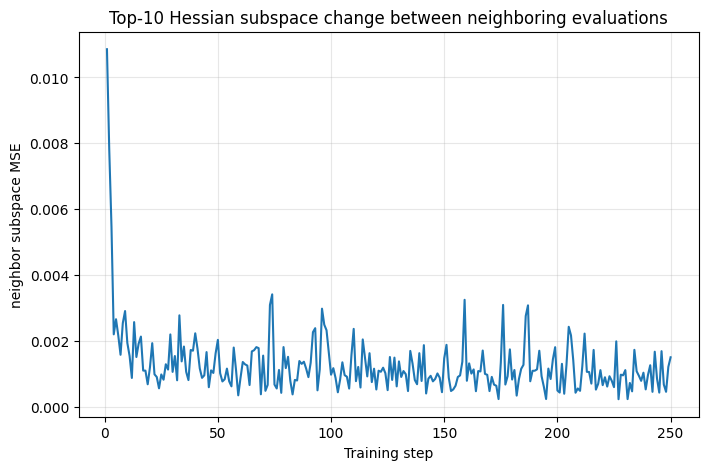

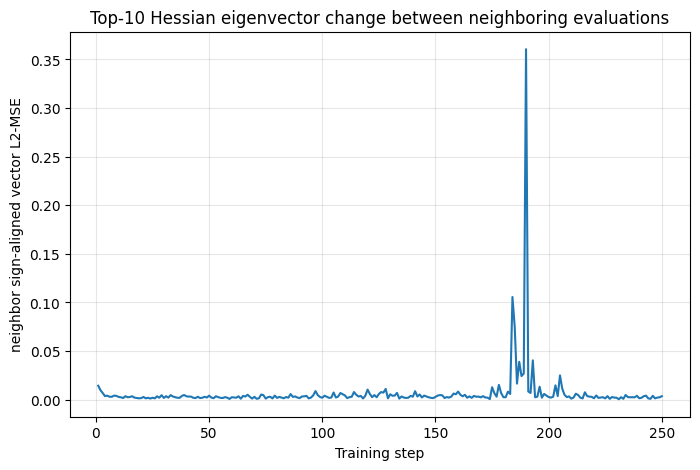

,step_prev,step,delta_steps,hessian_time_sec,neighbor_subspace_alignment,neighbor_subspace_mse,neighbor_min_principal_cosine,neighbor_mean_principal_cosine,neighbor_vector_mse_l2_mean,neighbor_vector_mse_l2_max
count,250.000000,250.000000,250.0,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000,250.000000
mean,124.500000,125.500000,1.0,0.136722,0.998712,0.001288,0.998745,0.999356,0.006287,0.022453
std,72.312977,72.312977,0.0,0.008512,0.001006,0.001006,0.001046,0.000504,0.024278,0.120828
min,0.000000,1.000000,1.0,0.123513,0.989146,0.000243,0.988994,0.994556,0.000460,0.000713
25%,62.250000,63.250000,1.0,0.130417,0.998438,0.000791,0.998478,0.999219,0.002060,0.003986
50%,124.500000,125.500000,1.0,0.133541,0.998920,0.001080,0.998971,0.999460,0.002996,0.006003
75%,186.750000,187.750000,1.0,0.142058,0.999209,0.001562,0.999247,0.999604,0.004346,0.010439
max,249.000000,250.000000,1.0,0.163897,0.999757,0.010854,0.999807,0.999879,0.360525,1.793023


In [ ]:
if len(neighbor_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(neighbor_df["step"], neighbor_df["neighbor_subspace_mse"])
    ax.set_xlabel("Training step")
    ax.set_ylabel("neighbor subspace MSE")
    ax.set_title(
        f"Top-{K_COMPARE} Hessian subspace change between neighboring evaluations"
    )
    ax.grid(True, alpha=0.3)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(neighbor_df["step"], neighbor_df["neighbor_vector_mse_l2_mean"])
    ax.set_xlabel("Training step")
    ax.set_ylabel("neighbor sign-aligned vector L2-MSE")
    ax.set_title(
        f"Top-{K_COMPARE} Hessian eigenvector change between neighboring evaluations"
    )
    ax.grid(True, alpha=0.3)
    plt.show()

    display(neighbor_df.describe())
else:
    print("neighbor_df is empty. Check FULL_COMPARE_EVERY and run length.")


## Plot 4: eigenvalue trajectories

График: одна линия — одно собственное число Hessian по training steps.

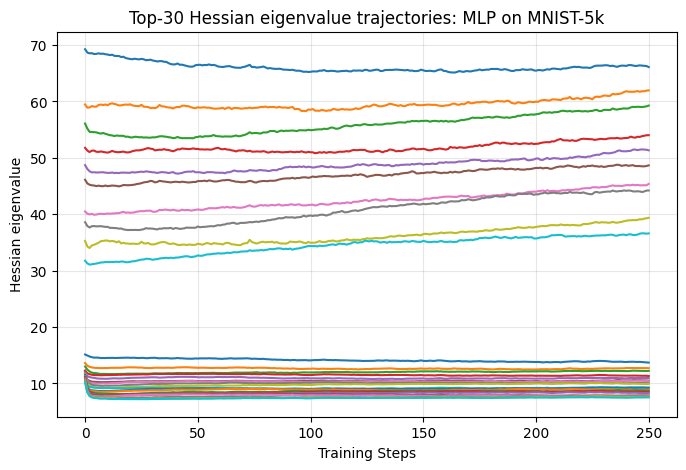

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

for eigen_idx, g in eig_df.groupby("eigen_idx"):
    ax.plot(
        g["step"], g["eigenvalue"], linewidth=1.5, label=f"$\\lambda_{int(eigen_idx)}$"
    )

ax.set_xlabel("Training Steps")
ax.set_ylabel("Hessian eigenvalue")
ax.set_title(f"Top-{K_SPECTRUM} Hessian eigenvalue trajectories: MLP on MNIST-5k")
ax.grid(True, alpha=0.3)

plt.show()

## Plot 5: low-dimensionality diagnostics

Проверяем, доминируют ли первые `k=10` направлений среди top-`K_SPECTRUM`.

- `topk_positive_mass_ratio`: доля положительной массы top-10 среди положительной массы top-K.
- `tail_to_topk_positive_mass`: отношение положительной массы хвоста после top-10 к положительной массе top-10.
- `eigengap_k_over_kplus1`: отношение `lambda_10 / lambda_11`.

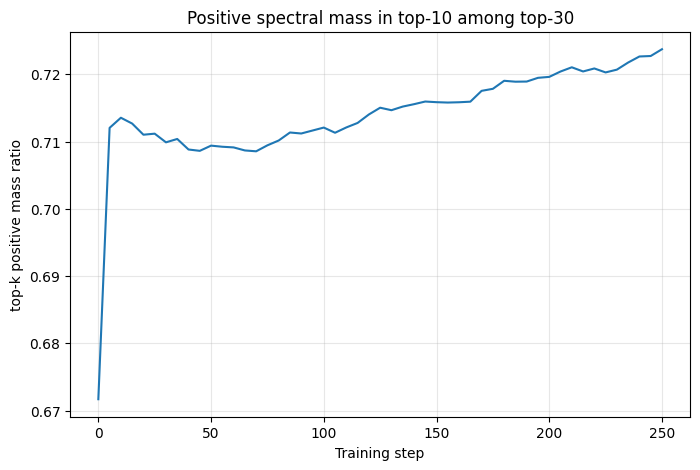

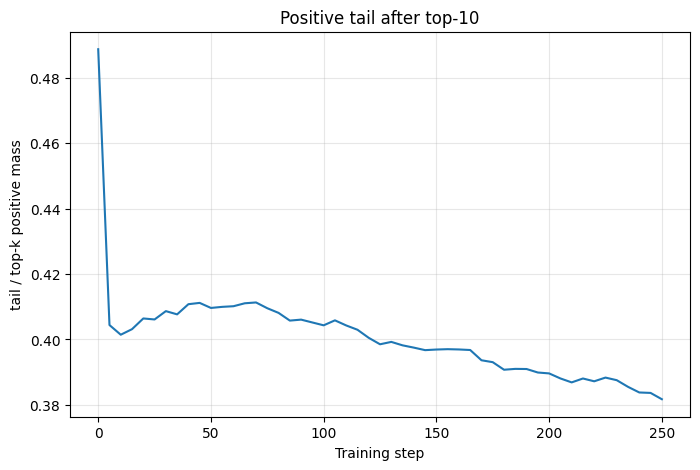

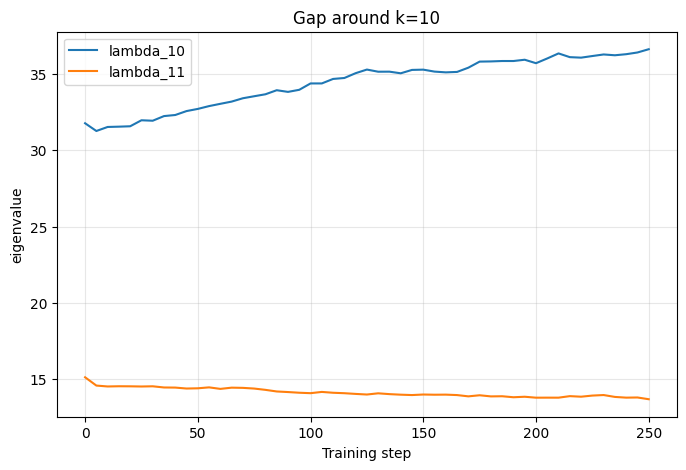

,step,hessian_time_sec,topk_positive_mass_ratio,tail_to_topk_positive_mass,eigengap_k_over_kplus1,lambda_1,lambda_10,lambda_11
count,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000,51.000000
mean,125.000000,0.659803,0.714053,0.400616,2.436427,66.125522,34.409797,14.141893
std,74.330344,0.024772,0.007553,0.015382,0.161819,0.902032,1.616202,0.297968
min,0.000000,0.629600,0.671678,0.381724,2.098507,65.227249,31.253311,13.698277
25%,62.500000,0.640704,0.711096,0.390856,2.296568,65.483826,33.104887,13.896444
50%,125.000000,0.657071,0.714663,0.399261,2.494513,65.766884,35.036980,14.045617
75%,187.500000,0.667809,0.718982,0.406281,2.582828,66.304455,35.819883,14.405747
max,250.000000,0.747306,0.723733,0.488808,2.672249,69.249451,36.605206,15.134580


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lowdim_df["step"], lowdim_df["topk_positive_mass_ratio"])
ax.set_xlabel("Training step")
ax.set_ylabel("top-k positive mass ratio")
ax.set_title(f"Positive spectral mass in top-{K_COMPARE} among top-{K_SPECTRUM}")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lowdim_df["step"], lowdim_df["tail_to_topk_positive_mass"])
ax.set_xlabel("Training step")
ax.set_ylabel("tail / top-k positive mass")
ax.set_title(f"Positive tail after top-{K_COMPARE}")
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    lowdim_df["step"], lowdim_df[f"lambda_{K_COMPARE}"], label=f"lambda_{K_COMPARE}"
)
if f"lambda_{K_COMPARE + 1}" in lowdim_df:
    ax.plot(
        lowdim_df["step"],
        lowdim_df[f"lambda_{K_COMPARE + 1}"],
        label=f"lambda_{K_COMPARE + 1}",
    )
ax.set_xlabel("Training step")
ax.set_ylabel("eigenvalue")
ax.set_title(f"Gap around k={K_COMPARE}")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

display(lowdim_df.describe())